# Employee Analytics｜Department Analysis

## 目的
架空の従業員データを用いて、DepartmentとJobTitleによる給与水準の違いを分析する。

## 分析内容
- Department別の平均TotalSalary
- Department × JobTitle別の平均TotalSalary
- データ生成時に設定した給与ルールとの整合性確認

# 架空企業の設定  
| 項目   | 内容                 |
| ---- | ------------------ |
| 会社名  | NextVision株式会社（架空） |
| 業種   | IT・Webサービス         |
| 従業員数 | 200人               |
| 分析対象 | 正社員のみ              |
| 勤務地  | 東京都（本社）            |
  
### 部署  


*   営業部（Sales）
*   開発部（Engineering）
*   人事部（Human Resources）
*   経理部（Finance）
*   マーケティング部（Marketing）
*   カスタマーサポート部（Customer Support）


### 役職  
*   Staff
*   Senior
*   Manager

# データ生成プログラムを作る

In [2]:
# ライブラリの読み込み
import pandas as pd
import numpy as np
import random

In [3]:
# 作成データに再現性を持たせる
random.seed(42)
np.random.seed(42)

In [4]:

# 社員数を決める
NUM_EMPLOYEES = 200

# 社員番号を作る
employee_ids = [
    f"EMP{str(i).zfill(4)}"
    for i in range(1, NUM_EMPLOYEES + 1)
]

# 最初の10件を確認
print(employee_ids[:10])

['EMP0001', 'EMP0002', 'EMP0003', 'EMP0004', 'EMP0005', 'EMP0006', 'EMP0007', 'EMP0008', 'EMP0009', 'EMP0010']


# 年齢・性別・部署を生成する

In [5]:
# 部署の候補を作る
departments = [
    "Sales",
    "Engineering",
    "Human Resources",
    "Finance",
    "Marketing",
    "Customer Support"
]

# 部署をランダムに割り当てる
department_list = random.choices(
    population=departments,
    weights=[25, 35, 10, 10, 10, 10],
    k=NUM_EMPLOYEES
)

In [6]:
# 年齢を作る
ages = np.random.randint(22, 61, NUM_EMPLOYEES)

In [7]:
# 性別
genders = random.choices(
    ["Male", "Female"],
    weights=[6, 4],
    k=NUM_EMPLOYEES
)

In [8]:
# DataFrameを作る
employee_df = pd.DataFrame({
    "EmployeeID": employee_ids,
    "Age": ages,
    "Gender": genders,
    "Department": department_list
})

employee_df.head()

,EmployeeID,Age,Gender,Department
0,EMP0001,60,Female,Human Resources
1,EMP0002,50,Female,Sales
2,EMP0003,36,Female,Engineering
3,EMP0004,29,Male,Sales
4,EMP0005,42,Male,Finance


# 勤続年数を追加する

In [9]:
years_at_company = []

for age in ages:
  max_years = max(0, age - 22)
  years = random.randint(0, min(max_years, 35))
  years_at_company.append(years)

In [10]:
# DataFrameに追加
employee_df = pd.DataFrame({
    "EmployeeID": employee_ids,
    "Age": ages,
    "Gender": genders,
    "Department": department_list,
    "YearsAtCompany": years_at_company
})

employee_df.head()

,EmployeeID,Age,Gender,Department,YearsAtCompany
0,EMP0001,60,Female,Human Resources,28
1,EMP0002,50,Female,Sales,21
2,EMP0003,36,Female,Engineering,3
3,EMP0004,29,Male,Sales,7
4,EMP0005,42,Male,Finance,5


In [11]:
employee_df.describe()

,Age,YearsAtCompany
count,200.000000,200.000000
mean,41.045000,9.285000
std,11.826339,8.556861
min,22.000000,0.000000
25%,30.000000,2.000000
50%,42.500000,7.000000
75%,51.000000,14.000000
max,60.000000,35.000000


In [12]:
employee_df["Department"].value_counts()

,count
Department,
Engineering,66
Sales,58
Marketing,22
Human Resources,21
Customer Support,19
Finance,14


# 役職（JobTitle）を作る

In [13]:
job_titles = []

for years in years_at_company:
  if years >= 12:
    job_titles.append("Manager")
  elif years >= 5:
    job_titles.append("Senior")
  else:
    job_titles.append("Staff")

for i in range(10):
  print(
      employee_ids[i],
      years_at_company[i],
      job_titles[i]
  )

EMP0001 28 Manager
EMP0002 21 Manager
EMP0003 3 Staff
EMP0004 7 Senior
EMP0005 5 Senior
EMP0006 5 Senior
EMP0007 9 Senior
EMP0008 16 Manager
EMP0009 10 Senior
EMP0010 10 Senior


In [14]:
employee_df["JobTitle"] = job_titles
employee_df["JobTitle"].value_counts()

,count
JobTitle,
Staff,74
Manager,65
Senior,61


In [15]:
employee_df.head()

,EmployeeID,Age,Gender,Department,YearsAtCompany,JobTitle
0,EMP0001,60,Female,Human Resources,28,Manager
1,EMP0002,50,Female,Sales,21,Manager
2,EMP0003,36,Female,Engineering,3,Staff
3,EMP0004,29,Male,Sales,7,Senior
4,EMP0005,42,Male,Finance,5,Senior


# 給与データを作る

In [16]:
import random

# Department別の基本給レンジ（架空データ生成用）
# 勤続年数に応じてレンジ内で昇給する
salary_ranges = {
    "Human Resources":  (210000, 220000),
    "Engineering":  (240000, 260000),
    "Sales":  (220000, 235000),
    "Finance": (215000, 230000),
    "Marketing":  (220000, 235000),
    "Customer Support": (210000, 220000)
}

# BaseSalary列を作成
employee_df["BaseSalary"] = 0

for i in range(len(employee_df)):
  department = employee_df.loc[i, "Department"]

  years = employee_df.loc[i, "YearsAtCompany"]

  min_salary, max_salary = salary_ranges[department]

  salary_width = max_salary - min_salary

  experience_ratio = min(years / 10, 1)

  base_salary = min_salary + salary_width * experience_ratio

  # ランダム補正
  base_salary += random.randint(-3000, 3000)

  # 下限チェック
  base_salary = max(min_salary, base_salary)

  # 上限チェック
  base_salary = min(max_salary, base_salary)

  base_salary = int(base_salary)

  employee_df.loc[i, "BaseSalary"] = base_salary

In [17]:
employee_df[
    [
        "EmployeeID",
        "Department",
        "YearsAtCompany",
        "BaseSalary"
    ]
].head(10)

,EmployeeID,Department,YearsAtCompany,BaseSalary
0,EMP0001,Human Resources,28,220000
1,EMP0002,Sales,21,232864
2,EMP0003,Engineering,3,246551
3,EMP0004,Sales,7,230467
4,EMP0005,Finance,5,224706
5,EMP0006,Human Resources,5,215766
6,EMP0007,Marketing,9,235000
7,EMP0008,Sales,16,233253
8,EMP0009,Engineering,10,260000
9,EMP0010,Sales,10,233442


# 給与レンジを超えていないか確認

In [18]:
employee_df.groupby("Department")["BaseSalary"].agg(["min","max","mean"])

,min,max,mean
Department,,,
Customer Support,210000,220000,215657.789474
Engineering,240000,260000,251885.651515
Finance,215000,230000,225545.285714
Human Resources,210033,220000,215765.619048
Marketing,220000,235000,229016.681818
Sales,220000,235000,228869.362069


# 役職手当(PositionAllowance)の実装

In [19]:
# 役職に応じた手当を設定
position_allowance = {
    "Staff":0,
    "Senior":20000,
    "Manager":50000
}

employee_df["PositionAllowance"] = employee_df["JobTitle"].map(position_allowance)

employee_df[[ "JobTitle", "PositionAllowance"]].head(10)

,JobTitle,PositionAllowance
0,Manager,50000
1,Manager,50000
2,Staff,0
3,Senior,20000
4,Senior,20000
5,Senior,20000
6,Senior,20000
7,Manager,50000
8,Senior,20000
9,Senior,20000


# 役職手当が想定どおりになっているか確認

In [20]:
employee_df.groupby("JobTitle")["PositionAllowance"].agg(["min", "max", "mean"])

,min,max,mean
JobTitle,,,
Manager,50000,50000,50000.0
Senior,20000,20000,20000.0
Staff,0,0,0.0


# 総支給額の列を追加する

In [21]:
# 給与 = 基本給 + 役職手当
employee_df["TotalSalary"] = employee_df["BaseSalary"] + employee_df["PositionAllowance"]
employee_df[["BaseSalary", "PositionAllowance", "TotalSalary"]].head(10)

,BaseSalary,PositionAllowance,TotalSalary
0,220000,50000,270000
1,232864,50000,282864
2,246551,0,246551
3,230467,20000,250467
4,224706,20000,244706
5,215766,20000,235766
6,235000,20000,255000
7,233253,50000,283253
8,260000,20000,280000
9,233442,20000,253442


In [22]:
employee_df["TotalSalary"].describe()

,TotalSalary
count,200.000
mean,255967.265
std,28648.883
min,210000.000
25%,233698.750
50%,252570.500
75%,278131.250
max,310000.000


In [23]:
employee_df.groupby("Department")['TotalSalary'].agg(["min", "max", "mean"])

,min,max,mean
Department,,,
Customer Support,210000,270000,239868.315789
Engineering,240000,310000,272491.712121
Finance,215000,280000,257688.142857
Human Resources,210033,270000,239575.142857
Marketing,220000,285000,248562.136364
Sales,220000,285000,250765.913793


# 役職別の給与を比較する

In [24]:
employee_df.groupby("JobTitle")["TotalSalary"].agg(["min", "max", "mean"])

,min,max,mean
JobTitle,,,
Manager,267446,310000,286976.584615
Senior,232372,280000,257835.754098
Staff,210000,250758,227189.108108


# 勤続年数と給与の関係を調べる

In [25]:
employee_df.groupby("YearsAtCompany")["TotalSalary"].mean()

,TotalSalary
YearsAtCompany,
0,222181.136364
1,225206.700000
2,224967.538462
3,234348.538462
4,241461.000000
5,252079.600000
6,256753.285714
7,255853.600000
8,261584.285714


# グラフで関係を見てみる

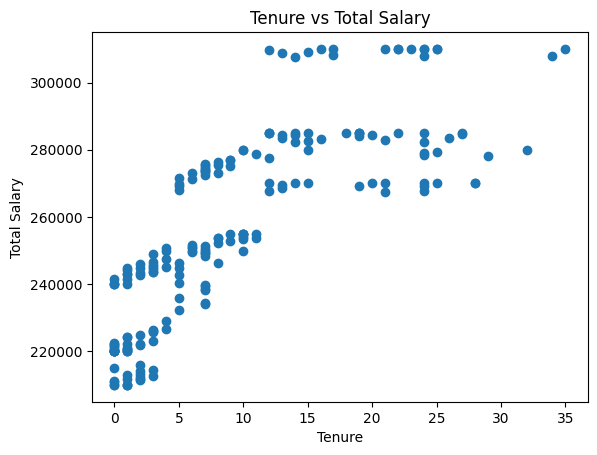

In [26]:
# ライブラリの読み込み
import matplotlib.pyplot as plt

# 散布図を作成する
Tenure = employee_df["YearsAtCompany"]
Total_Salary = employee_df["TotalSalary"]

plt.scatter(Tenure, Total_Salary)
plt.xlabel("Tenure")
plt.ylabel("Total Salary")
plt.title("Tenure vs Total Salary")
plt.show()


In [27]:
employee_df.groupby(["JobTitle", "YearsAtCompany"])["TotalSalary"].mean()

JobTitle  YearsAtCompany
Manager   12                282843.428571
          13                282913.600000
          14                285907.400000
          15                285340.400000
          16                296626.500000
          17                309062.000000
          18                285000.000000
          19                281650.400000
          20                277254.000000
          21                282577.500000
          22                301666.666667
          23                310000.000000
          24                285967.200000
          25                292348.250000
          26                283590.000000
          27                284895.500000
          28                270000.000000
          29                278034.000000
          32                280000.000000
          34                307840.000000
          35                310000.000000
Senior    5                 252079.600000
          6                 256753.285714
          7                 255853.600000
          8                 261584.285714
          9                 267340.400000
          10                259734.333333
          11                262479.666667
Staff     0                 222181.136364
          1                 225206.700000
          2                 224967.538462
          3                 234348.538462
          4                 241461.000000
Name: TotalSalary, dtype: float64

In [28]:
employee_df["YearsAtCompany"].corr(employee_df["TotalSalary"])

np.float64(0.8052045567735433)

生成したデータに設定した給与ルールと整合する強い正の相関が確認された

# 年齢と給与の関係を調べる

In [29]:
employee_df["Age"].corr(employee_df["TotalSalary"])

np.float64(0.542705042209482)

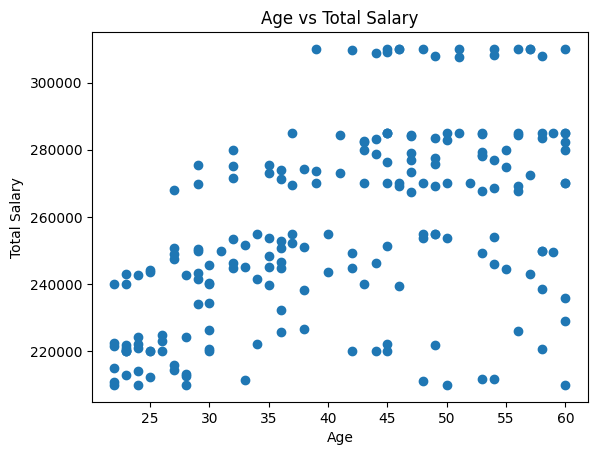

In [30]:
# 散布図を作成する
Age = employee_df["Age"]
Total_Salary = employee_df["TotalSalary"]

plt.scatter(Age, Total_Salary)
plt.xlabel("Age")
plt.ylabel("Total Salary")
plt.title("Age vs Total Salary")
plt.show()

年齢と給与には中程度の正の相関（r ＝ 0.543）が見られるが、勤続年数（r ＝ 0.805）ほど強い関係ではない。  
散布図からも、年齢だけでは給与水準を十分に説明できないことが確認できる。

# 給与と部署の関係を調べる

In [31]:
# 部署ごとの人数構成を調べる
employee_df["Department"].value_counts()

,count
Department,
Engineering,66
Sales,58
Marketing,22
Human Resources,21
Customer Support,19
Finance,14


In [32]:
# 部署ごとの給与水準の差を確認
employee_df.groupby("Department")["TotalSalary"].agg(
    ["min", "max", "mean", "median"]
).round(0)

,min,max,mean,median
Department,,,,
Customer Support,210000,270000,239868.0,239439.0
Engineering,240000,310000,272492.0,273280.0
Finance,215000,280000,257688.0,263768.0
Human Resources,210033,270000,239575.0,235766.0
Marketing,220000,285000,248562.0,250179.0
Sales,220000,285000,250766.0,251198.0


In [33]:
# 部署における役職の構成を調べる
pd.crosstab(
    employee_df["Department"],
    employee_df["JobTitle"],
).round(2)

JobTitle,Manager,Senior,Staff
Department,,,
Customer Support,8,3,8
Engineering,18,23,25
Finance,7,5,2
Human Resources,8,5,8
Marketing,5,9,8
Sales,19,16,23


In [34]:
# 部署ごとの役職構成を調べる
pd.crosstab(
    employee_df["Department"],
    employee_df["JobTitle"],
    normalize="index"
).round(2)

JobTitle,Manager,Senior,Staff
Department,,,
Customer Support,0.42,0.16,0.42
Engineering,0.27,0.35,0.38
Finance,0.50,0.36,0.14
Human Resources,0.38,0.24,0.38
Marketing,0.23,0.41,0.36
Sales,0.33,0.28,0.40


In [35]:
# 部署および役職ごとの給与の構成を調べる
employee_df.groupby(
    ["Department", "JobTitle"]
)["TotalSalary"].mean().round(0)

Department        JobTitle
Customer Support  Manager     269236.0
                  Senior      237835.0
                  Staff       211263.0
Engineering       Manager     309383.0
                  Senior      274327.0
                  Staff       244242.0
Finance           Manager     278929.0
                  Senior      244840.0
                  Staff       215467.0
Human Resources   Manager     269409.0
                  Senior      235834.0
                  Staff       212080.0
Marketing         Manager     284958.0
                  Senior      252020.0
                  Staff       221925.0
Sales             Manager     284112.0
                  Senior      252089.0
                  Staff       222299.0
Name: TotalSalary, dtype: float64

In [36]:
employee_df.groupby("Department")["TotalSalary"].mean()

,TotalSalary
Department,
Customer Support,239868.315789
Engineering,272491.712121
Finance,257688.142857
Human Resources,239575.142857
Marketing,248562.136364
Sales,250765.913793


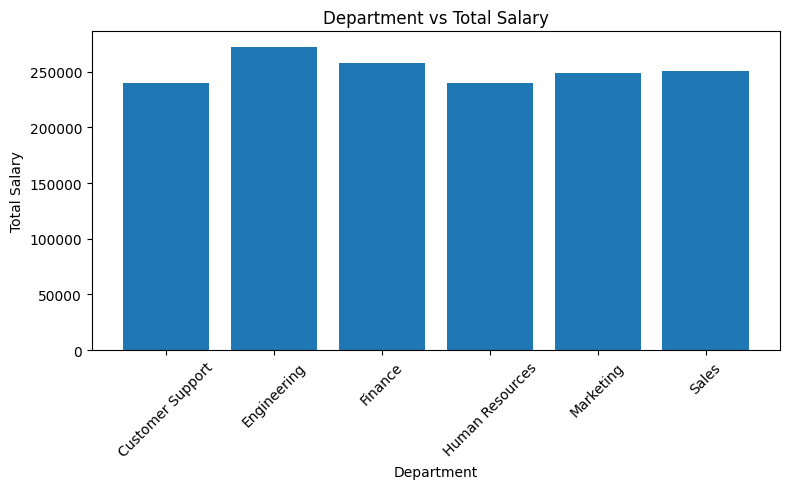

In [37]:
salary_by_department = employee_df.groupby("Department")["TotalSalary"].mean()

plt.figure(figsize=(8, 5))

plt.bar(salary_by_department.index, salary_by_department.values)
plt.xlabel("Department")
plt.ylabel("Total Salary")
plt.title("Department vs Total Salary")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("department_average_total_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Engineeringと他部署の差から言えること  

今回の分析では、
*   Engineeringの平均TotalSalary：272,492円
*   2番目に高いFinance：257,688円
*   最も低いHuman Resources：239,575円

なので、EngineeringはFinanceより約14,800円、Human Resourcesより約32,900円高くなっている。  
また、部署および役職別の平均給与について、Engineeringは

*   Staff：244,242円
*   Senior：274,327円
*   Manager：309,383円

と、すべての役職でほかの部署より高い結果だった。  

したがって、Engineeringの平均給与が高いのは、ManagerやSeniorが特に多いからではなく、同じ役職で比較しても給与水準が高いためと考えられる。  

また、今回のデータでは、Engineeringの基本給を他部署より高く設定していることが、Engineeringの高い給与につながっている。






# 部署および役職ごとの平均給与をグラフで表す

In [38]:
employee_df.groupby(
    ["Department", "JobTitle"]
)["TotalSalary"].mean()

Department        JobTitle
Customer Support  Manager     269235.750000
                  Senior      237835.000000
                  Staff       211263.375000
Engineering       Manager     309383.444444
                  Senior      274326.521739
                  Staff       244241.640000
Finance           Manager     278928.714286
                  Senior      244839.800000
                  Staff       215467.000000
Human Resources   Manager     269408.625000
                  Senior      235833.800000
                  Staff       212080.000000
Marketing         Manager     284958.200000
                  Senior      252019.777778
                  Staff       221924.750000
Sales             Manager     284112.052632
                  Senior      252088.750000
                  Staff       222298.869565
Name: TotalSalary, dtype: float64

In [39]:
salary_by_department_job = employee_df.groupby(
    ["Department", "JobTitle"]
)["TotalSalary"].mean()

salary_by_department_job

Department        JobTitle
Customer Support  Manager     269235.750000
                  Senior      237835.000000
                  Staff       211263.375000
Engineering       Manager     309383.444444
                  Senior      274326.521739
                  Staff       244241.640000
Finance           Manager     278928.714286
                  Senior      244839.800000
                  Staff       215467.000000
Human Resources   Manager     269408.625000
                  Senior      235833.800000
                  Staff       212080.000000
Marketing         Manager     284958.200000
                  Senior      252019.777778
                  Staff       221924.750000
Sales             Manager     284112.052632
                  Senior      252088.750000
                  Staff       222298.869565
Name: TotalSalary, dtype: float64

In [40]:
salary_by_department_job.index

MultiIndex([('Customer Support', 'Manager'),
            ('Customer Support',  'Senior'),
            ('Customer Support',   'Staff'),
            (     'Engineering', 'Manager'),
            (     'Engineering',  'Senior'),
            (     'Engineering',   'Staff'),
            (         'Finance', 'Manager'),
            (         'Finance',  'Senior'),
            (         'Finance',   'Staff'),
            ( 'Human Resources', 'Manager'),
            ( 'Human Resources',  'Senior'),
            ( 'Human Resources',   'Staff'),
            (       'Marketing', 'Manager'),
            (       'Marketing',  'Senior'),
            (       'Marketing',   'Staff'),
            (           'Sales', 'Manager'),
            (           'Sales',  'Senior'),
            (           'Sales',   'Staff')],
           names=['Department', 'JobTitle'])

In [41]:
labels = [
    department + " - " + job_title
    for (department, job_title) in salary_by_department_job.index
]
labels

['Customer Support - Manager',
 'Customer Support - Senior',
 'Customer Support - Staff',
 'Engineering - Manager',
 'Engineering - Senior',
 'Engineering - Staff',
 'Finance - Manager',
 'Finance - Senior',
 'Finance - Staff',
 'Human Resources - Manager',
 'Human Resources - Senior',
 'Human Resources - Staff',
 'Marketing - Manager',
 'Marketing - Senior',
 'Marketing - Staff',
 'Sales - Manager',
 'Sales - Senior',
 'Sales - Staff']

In [42]:
salary_by_department_job.unstack()

JobTitle,Manager,Senior,Staff
Department,,,
Customer Support,269235.750000,237835.000000,211263.375000
Engineering,309383.444444,274326.521739,244241.640000
Finance,278928.714286,244839.800000,215467.000000
Human Resources,269408.625000,235833.800000,212080.000000
Marketing,284958.200000,252019.777778,221924.750000
Sales,284112.052632,252088.750000,222298.869565


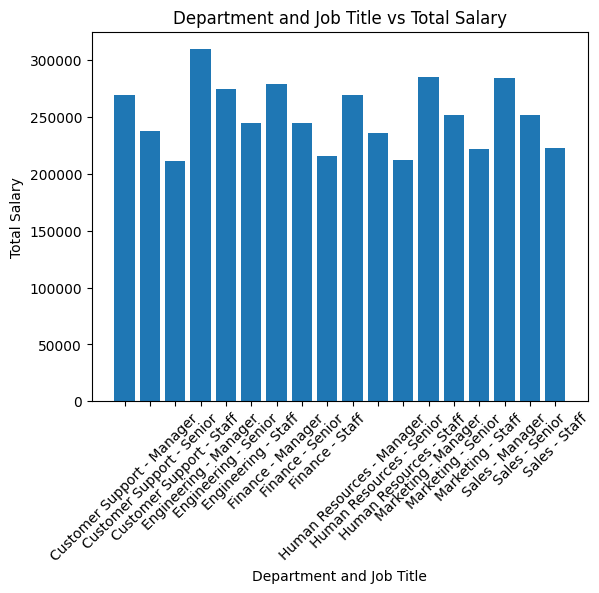

In [43]:
plt.bar(labels,salary_by_department_job.values)
plt.xlabel("Department and Job Title")
plt.ylabel("Total Salary")
plt.title("Department and Job Title vs Total Salary")
plt.xticks(rotation=45)
plt.show()

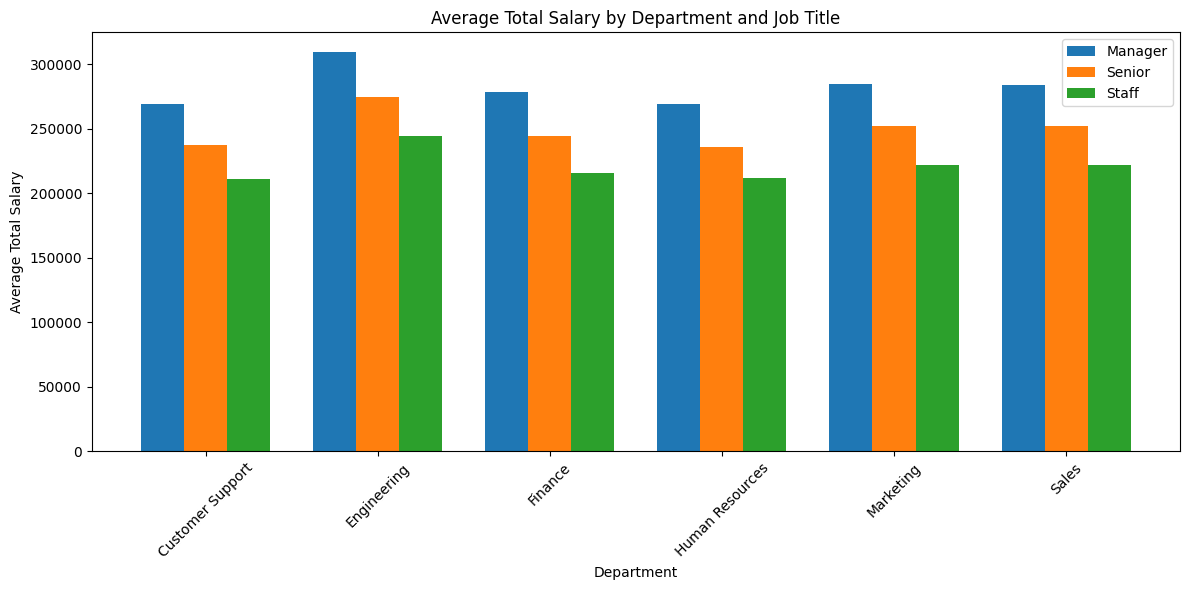

In [45]:
# 部署および役職ごとの平均給与をグラフ化する
salary_by_department_job_unstacked = salary_by_department_job.unstack()
x = np.arange(len(salary_by_department_job_unstacked))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, salary_by_department_job_unstacked["Manager"], width, label="Manager")
plt.bar(x, salary_by_department_job_unstacked["Senior"], width, label="Senior")
plt.bar(x + width, salary_by_department_job_unstacked["Staff"], width, label="Staff")

plt.xticks(x, salary_by_department_job_unstacked.index, rotation=45)
plt.xlabel("Department")
plt.ylabel("Average Total Salary")
plt.title("Average Total Salary by Department and Job Title")

plt.legend()
plt.tight_layout()

plt.savefig("department_jobtitle_average_total_salary.png", dpi=300, bbox_inches="tight")
plt.show()